# CivicRoute AI Course Assessment Starter Notebook

**Student name:**  Thomas Hart Lindland
**Student number:**  121894
**GitHub repository:**  https://github.com/limitsctrl/civicroute-AI/tree/main

This notebook supports the **revised structured-data assessment only**.

Use short, clearly labelled code sections. The assessment is not about producing a long notebook. Your aim is to create enough technical evidence to explain your decisions and results in the recorded video.

The notebook mainly supports:

- **Step 2:** Inspect and prepare the data with Pandas and NumPy.
- **Step 3:** Build one small TensorFlow/Keras model.
- **Step 4:** Record evidence for interpretation and explainability discussion.

GitHub workflow evidence, graph/GNN discussion and the final recommendation are demonstrated or discussed in the video rather than implemented here.


## Step 2: Inspect and prepare the data with Pandas and NumPy

### 2.1 Load and inspect the supplied dataset

Show the dataset shape, field names, data types, target-category counts and missing-value summary.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)

# Recommended repository structure:
# project/
# ├── civicroute_assessment.ipynb
# └── data/
#     └── civic_requests_prepared.csv

DATA_PATH = Path("data/civic_requests_prepared.csv")

# If you keep the CSV beside the notebook instead, this fallback will find it.
if not DATA_PATH.exists():
    DATA_PATH = Path("civic_requests_prepared.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)                   # Shows rows, columns

print("\nField names:")
print(list(df.columns))                            # all columns names

print("\nData types:")
print(df.dtypes)                            # number or text per column

print("\nCategory counts (%):")
counts = df["category_label"].value_counts() # requests per category
print(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(1)}))

print("\nMissing-value summary (%):")
missing = df.isna().sum()                      # missing values per column
print(pd.DataFrame({"missing": missing, "percent": (missing / len(df) * 100).round(1)}))
print(f"Total missing: {missing.sum()} of {df.size} values ({missing.sum() / df.size * 100:.2f}%)")
df.head()                                   # small preview (first 5 rows)


Shape: (600, 13)

Field names:
['request_id', 'created_hour', 'neighbourhood', 'channel', 'urgency_level', 'recent_rain_flag', 'night_report_flag', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count', 'previous_resolution_days', 'category_label']

Data types:
request_id                      str
created_hour                  int64
neighbourhood                   str
channel                         str
urgency_level                   str
recent_rain_flag                str
night_report_flag               str
repeat_report_count           int64
image_quality_score         float64
nearby_asset_age_years      float64
description_word_count        int64
previous_resolution_days    float64
category_label                  str
dtype: object

Category counts (%):
                    count  percent
category_label                    
pothole               150     25.0
water_leak            150     25.0
broken_streetlight    150     25.0
illegal_dumping 

,request_id,created_hour,neighbourhood,channel,urgency_level,recent_rain_flag,night_report_flag,repeat_report_count,image_quality_score,nearby_asset_age_years,description_word_count,previous_resolution_days,category_label
0,REQ-10001,18,North End,call_centre,medium,yes,yes,3,0.756,21.9,13,11.2,pothole
1,REQ-10002,8,Hillside,mobile_app,medium,yes,no,3,0.555,20.2,16,8.3,pothole
2,REQ-10003,20,Eastview,mobile_app,medium,no,yes,2,0.882,30.7,18,6.3,pothole
3,REQ-10004,11,South Park,mobile_app,medium,no,no,1,0.645,17.4,19,10.8,pothole
4,REQ-10005,20,Hillside,call_centre,medium,yes,yes,2,0.640,32.0,12,8.9,pothole


 **2.1** **Inspection Summary:**
- **Shape**          : From the shape output i see the dataset is small, so im keeping the model small.
- **Types**          : 7 text fields and 6 numeric, the text fields have to be encoded before modelling.
- **Category counts**: 4 categories, 150 per category, (25%), Baseline = 25%; accuracy is a fair metric score.
- **Missing values** : 23 of 7.800 values (0.29%), very little is missing, a simple method is enough.
- **Preview**        : Shows the 5 first rows of the data and its contents.

**Decision:** Base the preparation steps on these findings rather that applying them by default


In [2]:
pd.crosstab(df["night_report_flag"], df["created_hour"]) #count every flag x hour combination

created_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
night_report_flag,,,,,,,,,,,,,,,,,,,,,
no,0,0,0,0,0,0,30,29,23,28,...,29,23,31,20,0,0,0,0,0,0
yes,10,8,3,5,11,15,0,0,0,0,...,0,0,0,0,39,55,38,26,32,22


**Test:**
- Checking "night_report_flag" is a copy of "created_hour" (which it derived from).
- "yes" only appears at hours 0-5 and 18-23, "no" only at 6-17. There is zero overlap.
- The flag is fully determined by the hour, it is redundant and adds no new information.
- Dropping "night_report_flag", keeping "created_hour"-

### 2.2 Select the fields and identify the target

Choose the fields you believe are relevant to the prototype. Exclude identifiers and avoid using any field simply because it is available. State the target column clearly.


In [3]:
TARGET = "category_label"

INPUT_COLS = ["created_hour", "repeat_report_count", "image_quality_score",
                "nearby_asset_age_years", "description_word_count", "previous_resolution_days",
                "channel", "urgency_level", "recent_rain_flag"]                                  # selected inputs

# excluded : request_id (ID), night_report_flag (redundant), neighbourhood (fairness)

work_df = df[INPUT_COLS + [TARGET]].copy()                             # working DataFrame: inputs + target

print("Selected inputs:", INPUT_COLS)
print("Target:", TARGET)
print("Working shape:", work_df.shape)                                 # expect (600, 10)

Selected inputs: ['created_hour', 'repeat_report_count', 'image_quality_score', 'nearby_asset_age_years', 'description_word_count', 'previous_resolution_days', 'channel', 'urgency_level', 'recent_rain_flag']
Target: category_label
Working shape: (600, 10)


**2.2** **Decision**
- Use 9 input fields
- Exclueded "request_id" (TODO list), "night_report_flag"(redundant), "neighbourhood" (fariness)
- **Caution:** "previous_resolution_days" kept because the dictionary lists it as a feature, but flagged, invest for leakage?

### 2.3 Handle the small number of missing values

Use one sensible course-level method for the supplied missing values. Keep the code short and note why the method is appropriate so that you can explain the choice in your video.


In [4]:
before_missing = work_df.isna().sum()                                                                               # missing per column, "before"
print(f"Missing before: {before_missing.sum()} values")

fill_values = {
    "image_quality_score": work_df["image_quality_score"].median(),                                                 # median for numeric
    "previous_resolution_days": work_df["previous_resolution_days"].median(),
    "channel": work_df["channel"].mode()[0],                                                                        # mode for categorical
}
work_df = work_df.fillna(fill_values)                                                                               # fill each column with its value
after_missing = work_df.isna().sum()                                                                                # missing per column, "after"

for col, value in fill_values.items():                                                                              # one line per filled colunmn
    print(f"{col:<26} {before_missing[col]:>2} missing -> filled with {value} -> {after_missing[col]} missing")

print(f"Missing after: {after_missing.sum()} values")

Missing before: 23 values
image_quality_score        10 missing -> filled with 0.6935 -> 0 missing
previous_resolution_days    9 missing -> filled with 8.0 -> 0 missing
channel                     4 missing -> filled with mobile_app -> 0 missing
Missing after: 0 values


**2.3** **Decision: Missing values"**
 - Meidan for numeric fields, mode for channel
 - Only 23 values are missing, so simple method should be enough


### 2.4 Apply simple transformation or encoding

Prepare categorical data so that a neural network can use it. Use a short NumPy operation where it adds value, such as a vectorised numerical transformation or inspection of an array.


In [5]:
angle = 2 * np.pi * work_df["created_hour"].to_numpy() / 24                     # Numpy: hour -> angle on a clock
work_df["hour_sin"] = np.sin(angle)                                             # position on circle (x)
work_df["hour_cos"] = np.cos(angle)                                             # position on circle (y)
work_df["urgency"] = work_df["urgency_level"].map({"low": 0, "medium": 1, "high": 2})  # ordered -> 0/1/2
work_df["recent_rain"] = np.where(work_df["recent_rain_flag"] == "yes", 1, 0)          # yes/no -> 1/0
channel = pd.get_dummies(work_df["channel"], prefix="channel", dtype=float)            # one 0/1 column

X = work_df.drop(columns=["created_hour", "urgency_level", "recent_rain_flag", "channel",
                          TARGET]).join(channel)                                          # final numeric inputs

class_names = sorted(work_df[TARGET].unique())                                             # fixed aplhabetical order
class_to_id = {name: i for i, name in enumerate(class_names)}                              # name -> 0...3
y = work_df[TARGET].map(class_to_id).to_numpy()                                            # target as integers


**2.4** **Decision**
- Hour -> sin + cos (NumPy): hour is circular. plain numbers would put neighbours apart e.g. 23.00 and 00.00
- Urgency -> 0/1/2: low/medium/high is real order, so they keep that meaning
- Rain -> 1/0 with np.where
- Channel -> one-hot : channels has no order, numbering them would event one
- Target -> 0-3: network needs numbers

### 2.5 Confirm the model-ready data

Show the final model-ready shape or a small sample of the prepared data. Note what changed from the original dataset and why.


In [6]:
print("Original data:", df.shape)             # before
print("X:", X.shape, "| y:", y.shape)          # after: inputs and target
print("Missing in X:", X.isna().sum().sum())
print("Class mapping:", class_to_id)
X.head().round(3)

Original data: (600, 13)
X: (600, 13) | y: (600,)
Missing in X: 0
Class mapping: {'broken_streetlight': 0, 'illegal_dumping': 1, 'pothole': 2, 'water_leak': 3}


,repeat_report_count,image_quality_score,nearby_asset_age_years,description_word_count,previous_resolution_days,hour_sin,hour_cos,urgency,recent_rain,channel_call_centre,channel_mobile_app,channel_service_office,channel_web_portal
0,3,0.756,21.9,13,11.2,-1.000,-0.000,1,1,1.0,0.0,0.0,0.0
1,3,0.555,20.2,16,8.3,0.866,-0.500,1,1,0.0,1.0,0.0,0.0
2,2,0.882,30.7,18,6.3,-0.866,0.500,1,0,0.0,1.0,0.0,0.0
3,1,0.645,17.4,19,10.8,0.259,-0.966,1,0,0.0,1.0,0.0,0.0
4,2,0.640,32.0,12,8.9,-0.866,0.500,1,1,1.0,0.0,0.0,0.0


**2.5** **Model-ready shape**
- Before: 600 x 13 raw (text, missing values).
- After: X = 600 x 13 numeric inputs, y = 600 labels, 0 missing.
- Removed "request_id", "night_report_flag", "neigbourhood", hour-> 2 columns(sin,cos), channel-> 4 one-hot columns, text->numbers, gaps filled


## Step 3: Build one small TensorFlow/Keras model

The model should be deliberately modest. One or two hidden Dense layers are sufficient. No extensive tuning or competing models are required.


### 3.1 Create reproducible training, validation and test data


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_SEED)

keras.utils.set_random_seed(RANDOM_SEED)
# 70% train / 15% validation / 15 test, same class mix in each set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30,
                                                    stratify=y, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50,
                                                stratify=y_temp, random_state=RANDOM_SEED)

# Standardise with Training mean/std only
SCALE_cols = ["repeat_report_count", "image_quality_score", "nearby_asset_age_years",
              "description_word_count", "previous_resolution_days", "urgency"]
mpc = X_train[SCALE_cols].mean()                          # training mean per column
spc = X_train[SCALE_cols].std()                           # training std per column
X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()
for d in (X_train, X_val, X_test):
    d[SCALE_cols] = (d[SCALE_cols] -mpc) / spc            # -> mean 0, std 1

print("train:", X_train.shape, np.bincount(y_train))      # rows + count per class
print("val:  ", X_val.shape, np.bincount(y_val))
print("test: ", X_test.shape, np.bincount(y_test))

train: (420, 13) [105 105 105 105]
val:   (90, 13) [23 22 22 23]
test:  (90, 13) [22 23 23 22]


- Split 70/15/15: train 420(learn), validation 90 (watch overfitting, earlystop?), test 90 (one final honest score)
- Stratified: each set keeps 25% per cat,
- scaling after the split: asset age (0-55) and image score (0-1) put on same scale, using training mean/std only, test data dosent influence

### 3.2 Define a small Sequential classification model


In [8]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(len(class_names), activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044 (4.08 KB)

 Trainable params: 1,044 (4.08 KB)

 Non-trainable params: 0 (0.00 B)

**3.2** **Define Model**
- Dense(32,ReLU) -> Dense(16,ReLU) -> Dense(4,softmax), 1044 parameters.
- Only 420 training rows, bigger network could memorise, instead of learning
- ReLU lets the network leanr combinations (e.g. old asset "and" rain).
- Softmax gives 4 probabilities that sum to 1, the highest one is used as model confidence

### 3.3 Compile and train the model


In [9]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),           # Adam , default learning rate
              loss="sparse_categorical_crossentropy",                          # multi-class, integer labels
              metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                           restore_best_weights=True)          # stop when validation stops improving
history = model.fit(X_train.to_numpy(), y_train,
                   validation_data=(X_val.to_numpy(), y_val),                  # checked every epoch
                   epochs=80, batch_size=32,                                   # max 80 passes, 32 rows per update
                   callbacks=[early_stop], verbose=0)

best_epoch = int(np.argmin(history.history["val_loss"])) + 1                   # epochs with lowest validation loss
print(f"Epochs run: {len(history.history["loss"])} | best epoch: {best_epoch}")


Epochs run: 45 | best epoch: 35


**3.3 Compile and Train**
- **Loss:** sparse categorical cross-entropy.
- **Optimiser:** Adam (lr=0.001) adapts its steps size, works well without tuning.
- **Early Stopping:** max 80 epochs, stop if validation loss dosent improve for 10 turn, keep best weight.

### 3.4 Show the training and validation behaviour


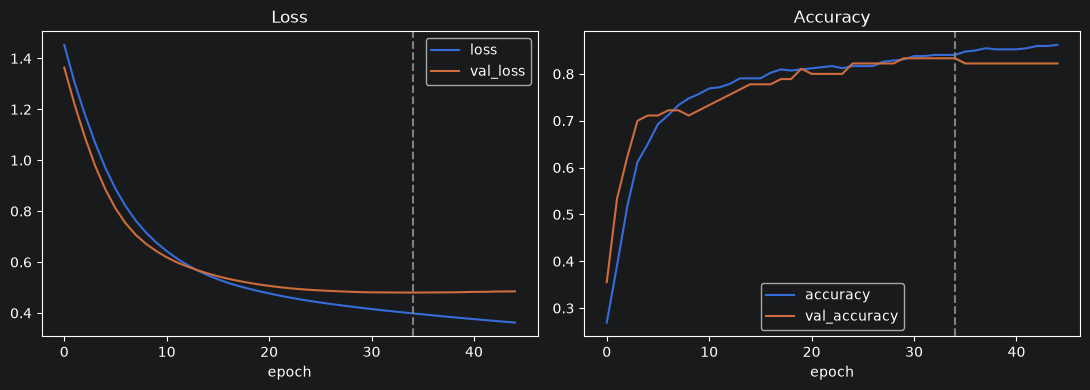

In [10]:
hist = pd.DataFrame(history.history)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
hist[["loss", "val_loss"]].plot(ax=ax[0], title="Loss")
hist[["accuracy", "val_accuracy"]].plot(ax=ax[1], title="Accuracy")
for a in ax:
    a.axvline(best_epoch - 1, ls="--", color="grey")
    a.set_xlabel("epoch")
plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=150)
plt.show()

**3.4 Training and Validation behaviour**
- Learning: both losses fall together until about epoch 12-16.
- Start of overfitting after that, training loss keeps falling while validation flattens.
- Early stopping kept the weights from epoch 35, lowest validation loss, training stopped 10 epochs later.
- No serious overfitting, training and validation accuracy are close.

### 3.5 Evaluate the prototype

Report overall test accuracy and produce a confusion matrix. These are the main outputs you will use when explaining one strength, one weakness or risky error, and what should happen next.


Test accuracy: 0.800 (baseline with 4 balaced classes: 0.250)


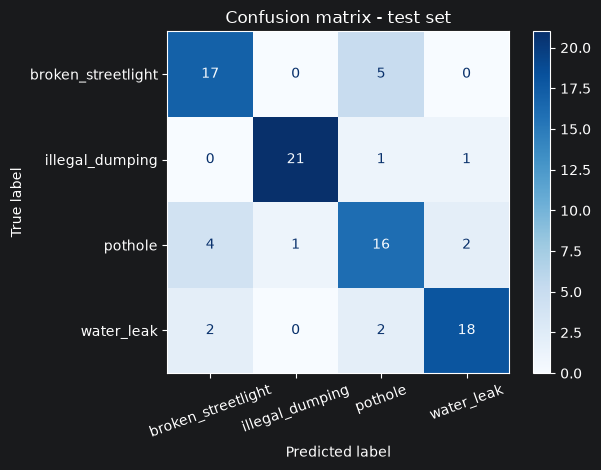

In [11]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(X_test.to_numpy(), y_test, verbose=0)

# print the overall test accuracy
print(f"Test accuracy: {test_acc:.3f} (baseline with 4 balanced classes: 0.250)")

# Generate test predictions
probab = model.predict(X_test.to_numpy(), verbose=0)           # probability for each of the 4 classes
y_pred = probab.argmax(axis=1)                                 # highest probability = predicted class

# Produce and display a confusion matrix
cm = confusion_matrix(y_test, y_pred)                          # rows = truth, columns = prediction
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=20)
plt.title("Confusion matrix - test set")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

## Step 4: Interpretation and explainability notes

No XAI library needs to be implemented in this notebook. Use the evidence above to prepare for the video discussion.

Record brief notes for yourself:

1. **Training vs Validation** (What do the training and validation results suggest about the model)
- Both losses fall together until around 12 epoch, so the model learns patterns that work in new data.
- Training loss keeps falling while validation loss flattens at (0,48), the model starts memorising (overfitting)
- Early Stopping kept the weights from epoch 35, where validation loss was lowest.
- Training and validation accuracy stay close, so the overfitting is mild, not serious
2. **Test results and confusion matrix.** (What does the test result and confusion matrix reveal?)
- Test accuracy 0.800 vs 25%, the error rate drops from 75% to 20%.
- With only 90 test rows, one case is about 1.1 points, so 0.800 is an estimate.
3. **Strength and risky error.** (What is one useful strength and one important weakness or risky error?)
- Strength: "illegal_dumping", 21 of 23 correct.
- Weakness: "pothole" <-> "broken_streetlight", 5 + 4 = 9, of the 18 errors. Both are you can say in similar "fields".
- Risky error: 4 of 22 water leaks routed to the wrong category. Leaky water can cause big damage, which can become costly.
4. **Model-agnostic vs model-specific** (Compare one **model-agnostic** explanation method and one **model-specific** explanation method from the course).
- Model-agnostic: Lime, SHAP, Permutation importance; "Agnostic" (meaning it does not care what kind of model),
5. Which explanation approach is more appropriate for this tabular prototype, and why?
6. What additional evidence or improvement would make you more confident in CivicRoute AI?


## Step 5 reminder: Graph-based modelling and GNNs

**No graph or GNN implementation is required.**

Prepare to explain in the video:

- useful node types;
- useful relationships or edges;
- one question a graph representation could help investigate;
- where a GNN could add value if CivicRoute AI became more relationship-driven; and
- whether a GNN is justified for the current prototype or should be considered later.


## Step 6 reminder: GitHub evidence

Keep this notebook and the selected supporting evidence in your GitHub repository.

Your video must demonstrate the GitHub workflow required by the assessment brief, including:

- a meaningful local change followed by add, commit and push;
- a remote change followed by pull;
- a branch-and-merge workflow;
- repository history; and
- how the README and file structure support reproducibility.

Commit meaningful milestones as you work rather than making one large final commit.


## Final recommendation notes

Before recording the final part of your video, return to the central question:

**Based on the evidence from your small prototype, what does CivicRoute AI appear capable of, what should be treated with caution, and what should the council do next?**

Base your recommendation on the evidence produced in this notebook rather than on accuracy alone.
